# **Задание №3. Разработка UML-диаграмм для проектирования информационной системы**

## **Цель задания**

На основе ранее разработанной концептуальной основы дипломного проекта спроектировать основные UML-диаграммы, необходимые для моделирования вашей информационной системы.

### **1. Диаграмма классов**

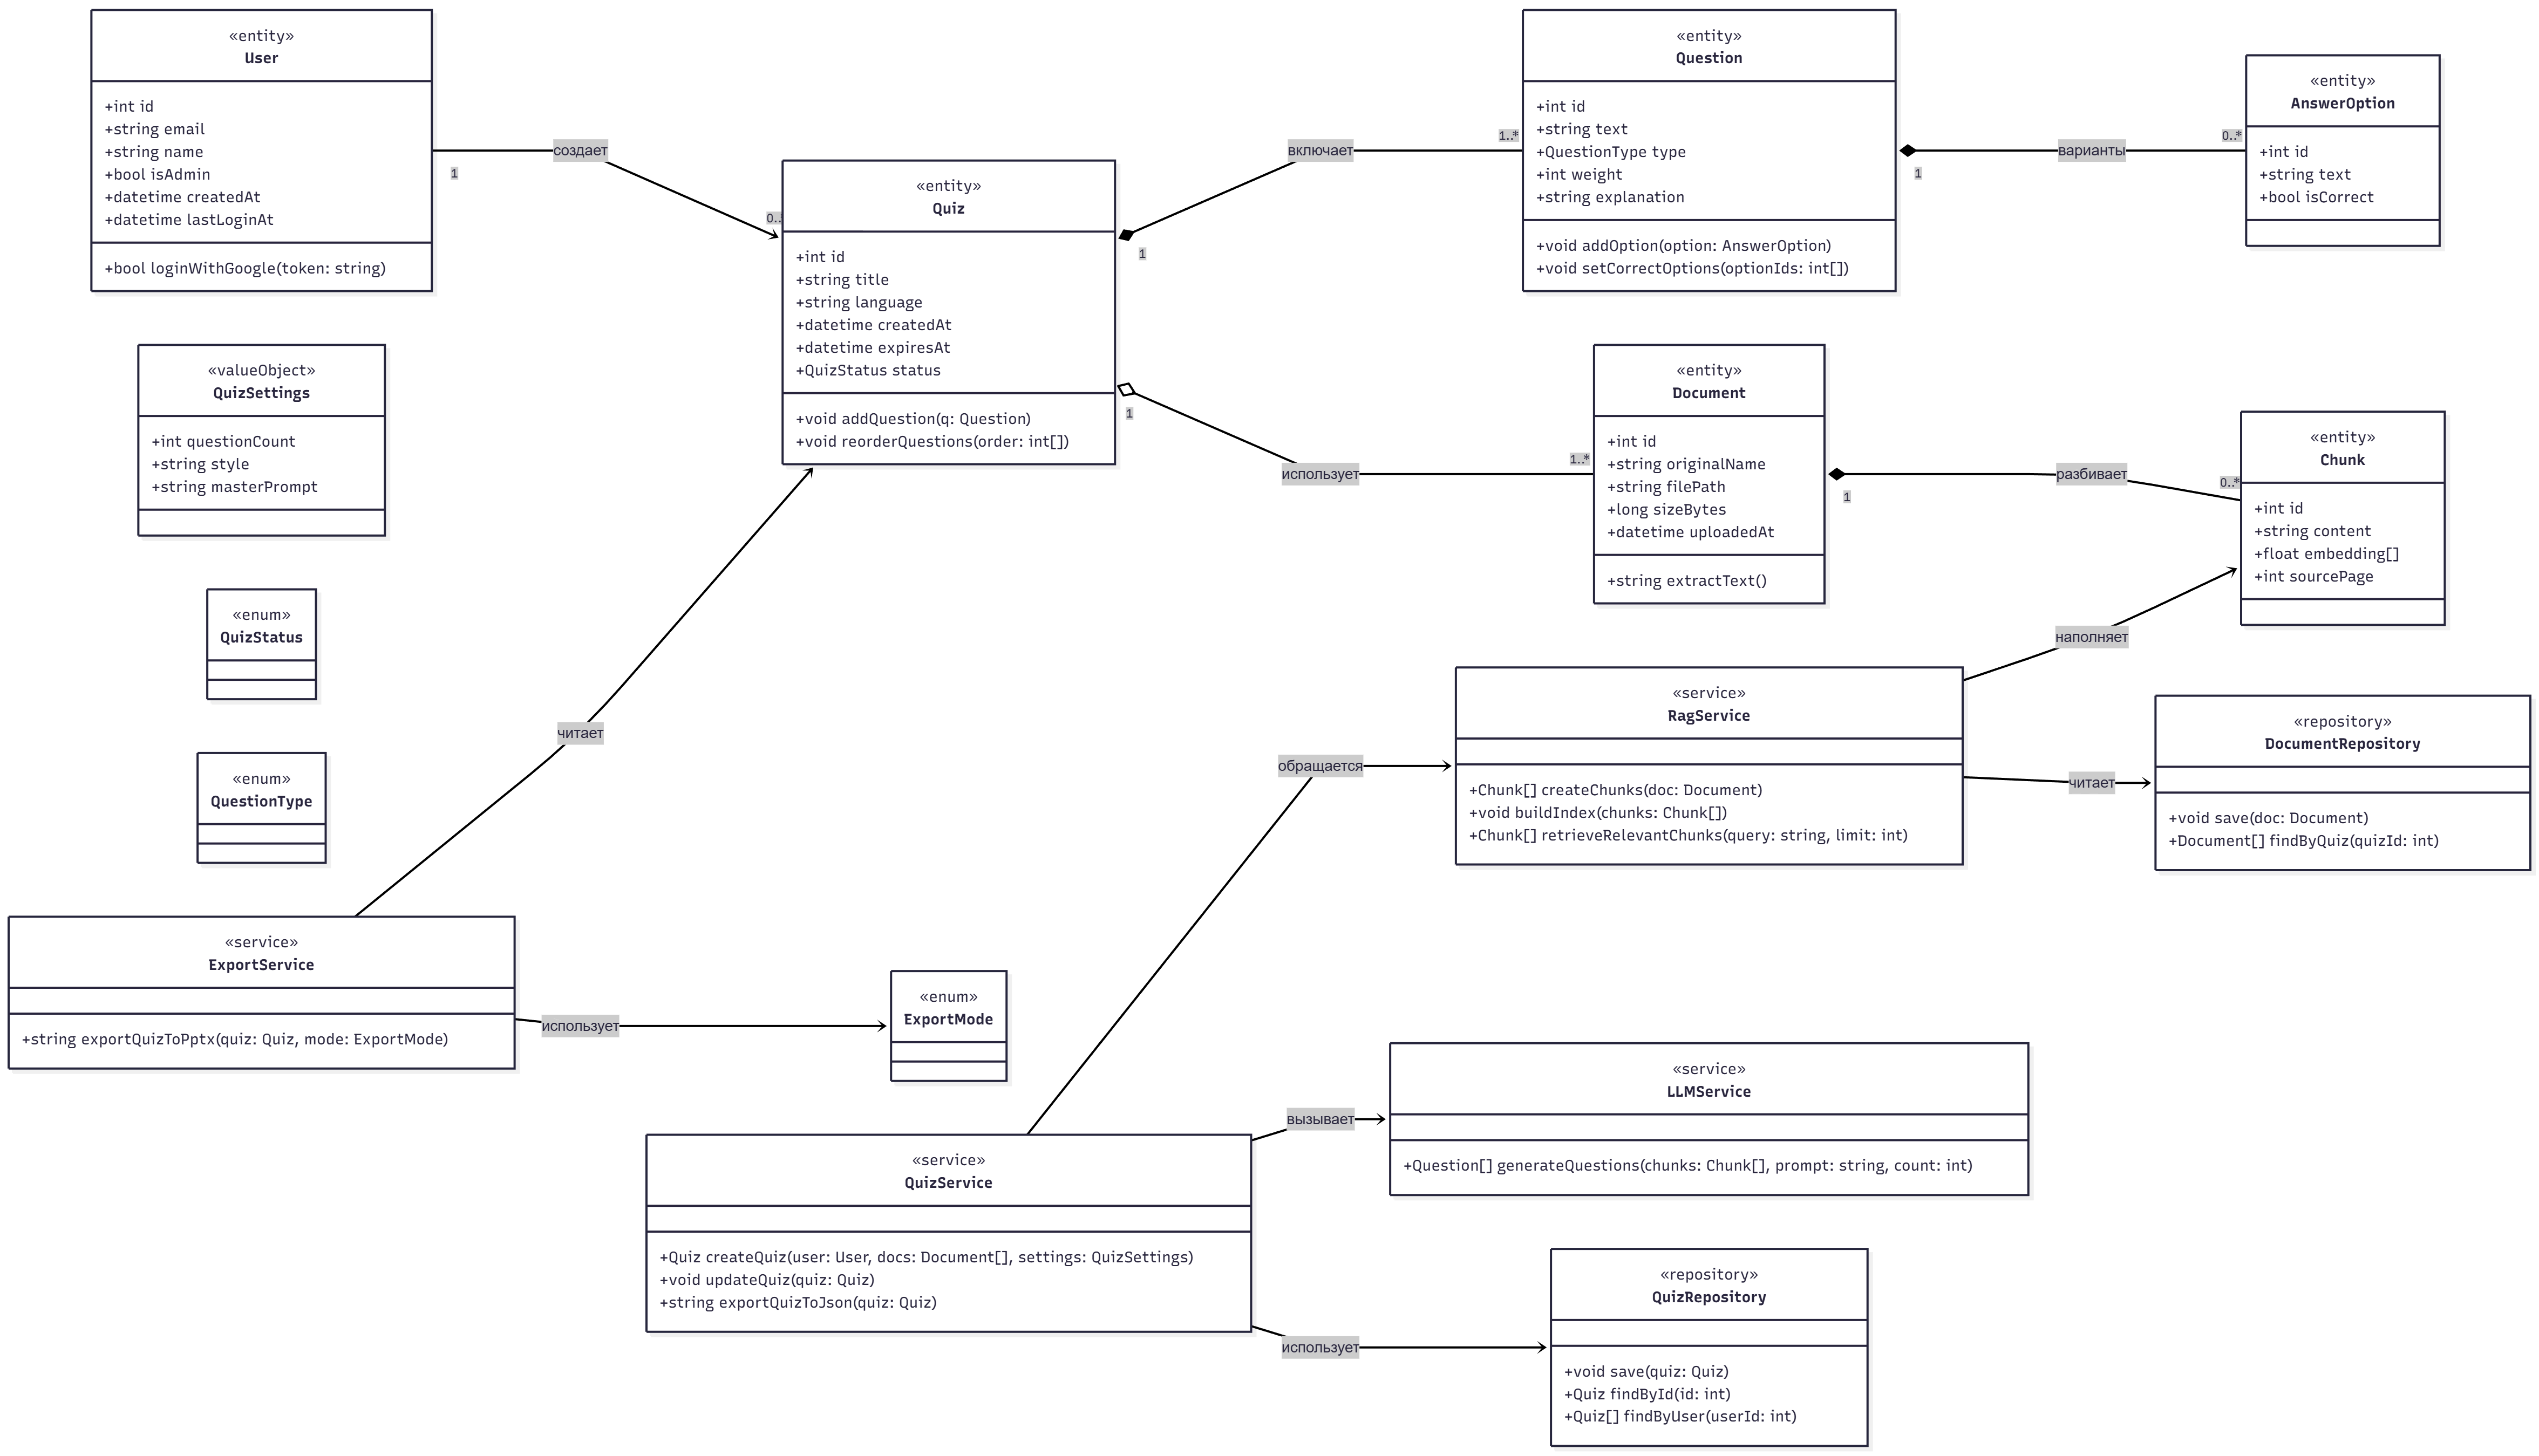

## **Основные классы**

### **User (Пользователь)**

Представляет авторов квизов и администраторов.
Содержит атрибуты email, имя, статус администратора и дату последнего входа.
Предоставляет метод для авторизации через Google OAuth и логики обновления пользовательских данных.

### **Quiz (Квиз)**

Представляет итоговый набор вопросов, созданных на основе документов.
Хранит название, язык, дату создания, срок хранения и список вопросов.
Предоставляет методы для добавления и сортировки вопросов.

### **Question (Вопрос)**

Представляет отдельный вопрос квиза.
Содержит текст вопроса, тип (одиночный выбор, множественный выбор, открытый или соответствие), вес и список вариантов ответов.
Включает методы добавления вариантов ответов и определения правильных ответов.

### **AnswerOption (Вариант ответа)**

Описывает текст одного варианта ответа и отмечает, является ли он правильным.
Используется внутри вопросов, связанных через композицию.

### **Document (Документ)**

Хранит сведения об исходных файлах пользователя: путь, размер и название.
Содержит метод извлечения текста для дальнейшей обработки.

### **Chunk (Фрагмент текста)**

Представляет собой часть документа после разбиения.
Хранит текстовый фрагмент, embedding-вектор и номер страницы, на которой он расположен.

### **QuizSettings (Настройки квиза)**

Включает параметры генерации: количество вопросов, стиль формулировки и мастер-промпт.
Используется при вызове LLM для формирования квиза.

## **Сервисные классы**

### **QuizService**

Реализует бизнес-логику: создание квиза, обновление структуры и экспорт JSON.
Использует RagService, LLMService и репозитории данных.

### **RagService**

Отвечает за извлечение текста, создание чанков и векторный поиск.
Связан с DocumentRepository и Chunk.

### **LLMService**

Инкапсулирует взаимодействие с локальной моделью Llama.
Генерирует набор вопросов на основе релевантных чанков.

### **ExportService**

Создаёт PowerPoint презентацию из готовой структуры квиза.
Работает с файловым хранилищем.

## **Отношения между классами**

**Композиция** – Quiz состоит из Questions, а Question – из AnswerOptions. Удаление квиза приводит к удалению всех связанных сущностей.

**Агрегация** – Quiz использует загруженные Document, но документы могут быть переработаны повторно.

**Ассоциация** – User связан с несколькими Quiz, поскольку каждый пользователь может создавать один активный и множество старых квизов.

**Зависимость** – сервисные классы используют репозитории и модули RAG и LLM.


### **2. Диаграмма вариантов использования**

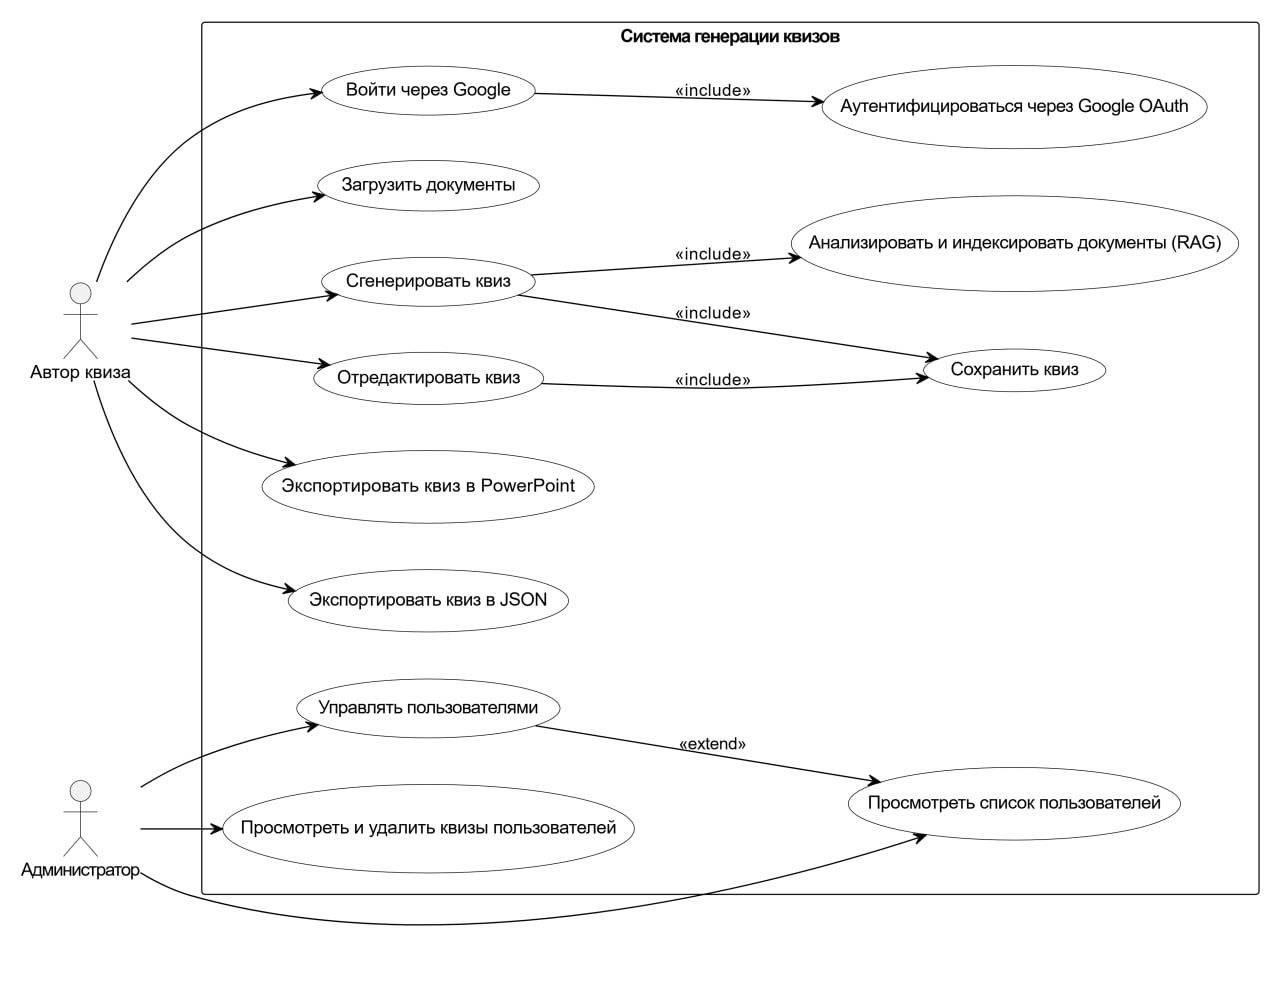

## Пояснения к диаграмме

### ✔ Акторы:

* **Пользователь** — базовый актор, может загружать материалы, генерировать и скачивать квизы.
* **Руководитель проекта**, **Разработчик** и **Администратор** наследуют функциональность пользователя.
* **Руководитель проекта** — управляет проектами, участниками, статистикой.
* **Разработчик** — работает с задачами (создание, изменение статуса, комментарии).
* **Администратор** — управляет пользователями системы.


## ✔ Основные варианты использования:

Включены как функционал системы генерации квизов (загрузка, обработка текста, генерация, редактирование, экспорт), так и элементы управления проектами из исходного задания.


## ✔ Отношения:

### **Include**

* Загрузка материалов → Обработка документов
* Обработка → Генерация квиза
* Создание проекта включает управление участниками
* Управление участниками включает назначение задачи
* Создание задачи включает назначение задачи

### **Extend**

* Изменение статуса задачи расширяется комментированием
* Просмотр статистики расширяется созданием отчёта


### **3. Диаграмма последовательности**

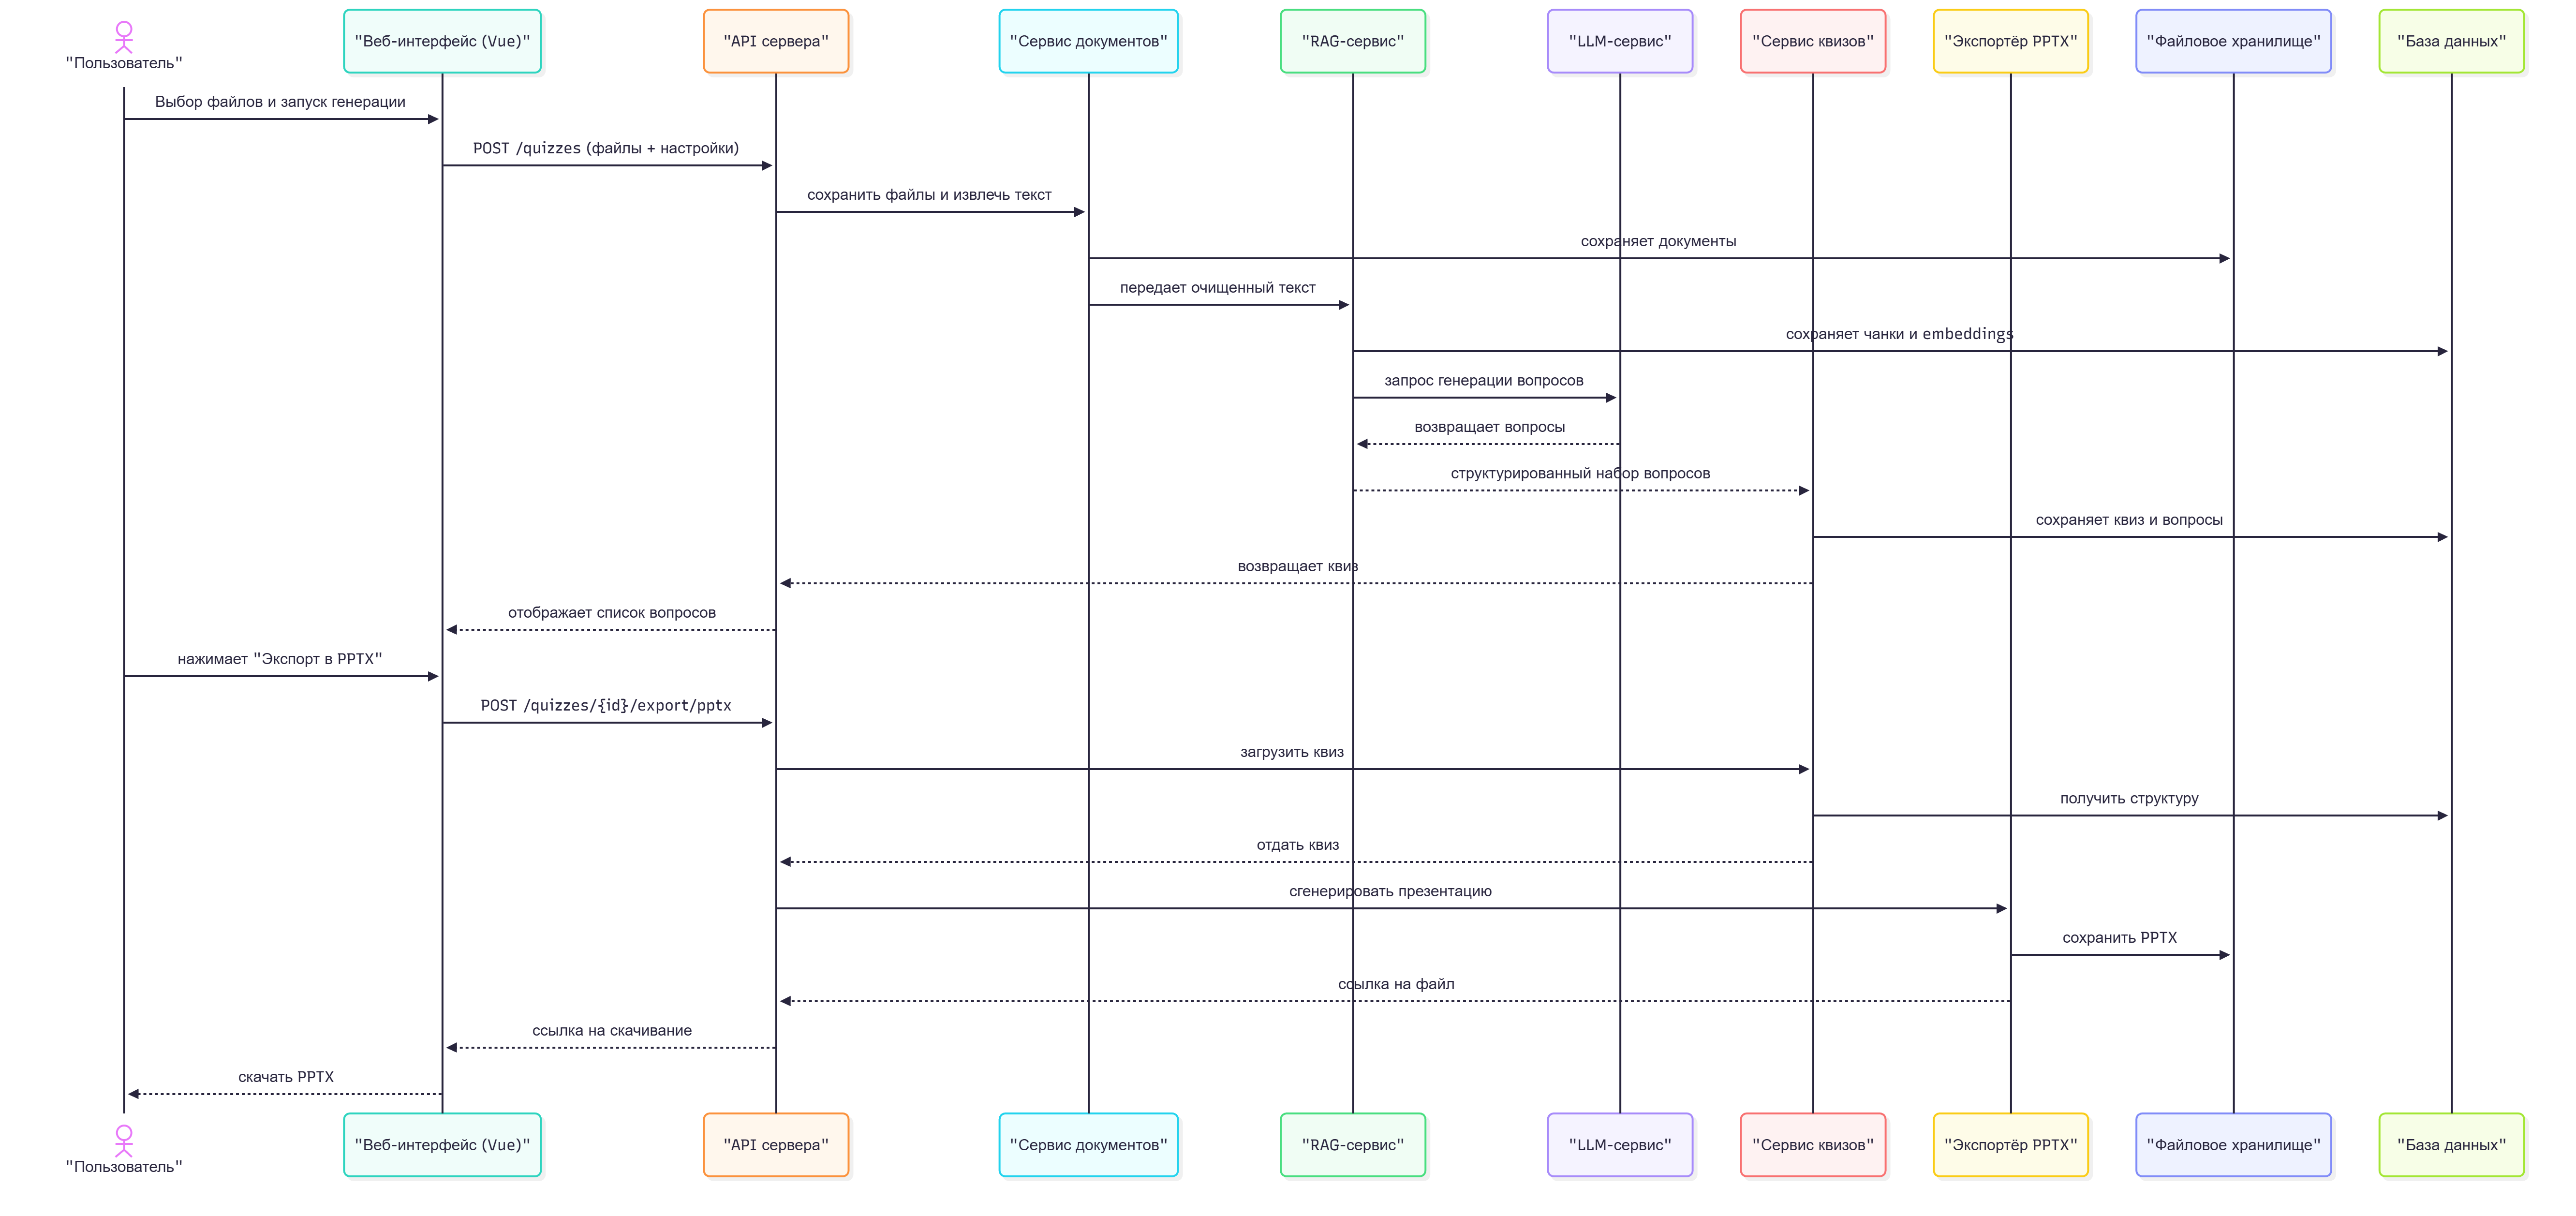

## Описание диаграммы последовательности

## **Участники процесса**

**Пользователь** – инициирует процесс загрузки документов, редактирует и экспортирует квиз.

**Web-интерфейс** – SPA-клиент на Vue, выполняющий отправку файлов, отображение квиза и вызов экспорта.

**API сервера** – маршрутизирует запросы, вызывает модули бизнес-логики и управляет состоянием.

**Сервис документов** – отвечает за сохранение файлов и извлечение текста.

**RAG-сервис** – выполняет чанкинг и поиск релевантных фрагментов.

**LLM-сервис** – генерирует вопросы на основе переданного контекста.

**Сервис квизов** – обрабатывает бизнес-логику сохранения и настройки квиза.

**Экспортёр PPTX** – формирует финальную презентацию.

**Файловое хранилище** – сохраняет PPTX и исходные документы.

**База данных** – хранит квизы, документы, чанки и пользователей.

## **Описание процесса**

### **1. Инициация пользователем**

Пользователь выбирает документы и отправляет их на сервер. Клиент формирует POST-запрос с файлами и настройками.

### **2. Парсинг и подготовка данных**

API отправляет файлы в сервис документов, который извлекает текст и передает его в RAG-сервис для разбиения на чанки и векторизации.

### **3. Генерация вопросов**

RAG-сервис вызывает локальную LLM, передавая релевантные фрагменты. LLM возвращает набор вопросов в структурированном виде.

### **4. Сохранение квиза**

QuizService сохраняет вопросы и структуру квиза в базе данных и возвращает клиенту данные для отображения.

### **5. Редактирование и экспорт**

Когда пользователь завершает правки, он инициирует экспорт. API вызывает PptxExporter, который создает презентацию и помещает её в файловое хранилище.

### **6. Завершение процесса**

API возвращает ссылку на скачивание, а пользователь получает итоговый PPTX-файл.

Диаграмма показывает полный рабочий цикл, а также отражает взаимодействие между различными модулями системы.

### **4. Диаграмма компонентов**

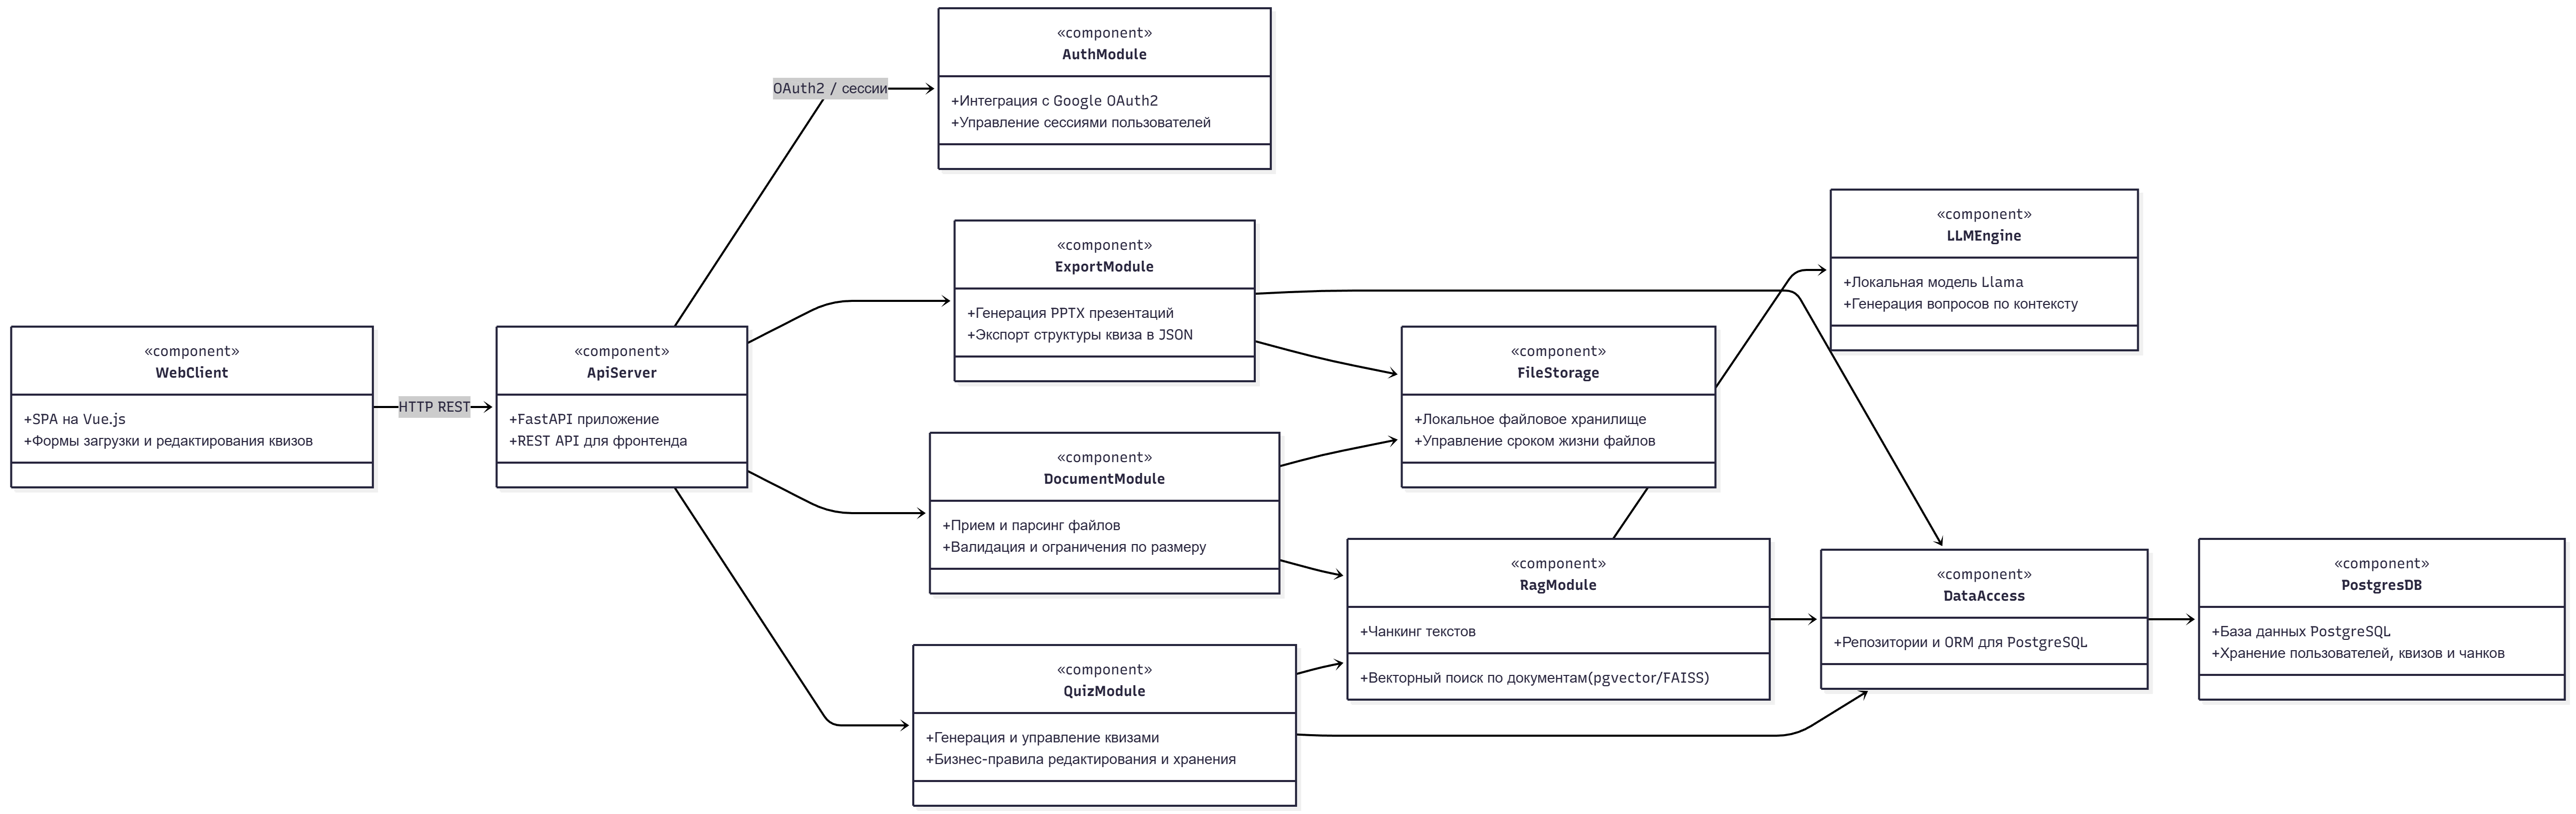

## Описание диаграммы компонентов
## **Основные уровни и компоненты**

### **Уровень представления**

**WebClient** – фронтенд на Vue.js.
Отвечает за интерфейс загрузки документов, отображение квиза, редактирование вопросов и экспорт.

### **Уровень бизнес-логики**

**ApiServer** – FastAPI приложение, принимающее запросы и передающее их в соответствующие модули.
**AuthModule** – реализует аутентификацию через Google OAuth2.
**QuizModule** – управляет созданием и редактированием квизов.
**DocumentModule** – обслуживает загрузку файлов и извлечение текста.
**RagModule** – создаёт чанки, embeddings и вызывает векторный поиск.
**LLMEngine** – локальная модель Llama для генерации вопросов.
**ExportModule** – формирует PPTX и JSON файлы.

### **Уровень доступа к данным**

**DataAccess** – репозитории для работы с PostgreSQL.
**FileStorage** – локальное хранилище документов и презентаций.

### **Хранилище данных**

**PostgresDB** – реляционная база данных.
Хранит пользователей, квизы, документы, чанки и настройки.

## **Взаимодействие и интерфейсы**

**WebClient** обращается к **ApiServer** через REST API.
**ApiServer** вызывает бизнес-модули, каждый из которых взаимодействует только со своей областью ответственности.
Слабая связанность обеспечивается тем, что модули работают через интерфейсы, что позволяет заменять реализацию без изменения других модулей (например, заменить FileStorage на S3).
Векторный поиск интегрирован в RAG-модуль, который вызывает LLMEngine только после предварительного анализа документа.